# Engenharia de Features
Este notebook tem como objetivo:
- Definir estratégia inicial de modelagem a partir dos dados brutos
- Criar e tratar variáveis explicativas
- Definir e tratar a variável alvo
- Garantir que as variáveis explicativas sejam claras e de fácil explicação para stakeholders

# Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

### Leitura de dados

In [32]:
df_unica = pd.read_csv('Data/processed/base_modelagem.csv')
df_unica['data'] = pd.to_datetime(df_unica['data'])
df_unica.head()

,codigo_filial,data,faturamento,quantidade,quantidade_tickets,meta_n_med,faixa_vida,localidade,uf,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas,evento
0,1500,2025-01-01,18077.83704,828.0,0,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.0388,NÃO,NÃO,NÃO,Confraternização mundial
1,1500,2025-01-02,18077.83704,828.0,138,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.0388,NÃO,NÃO,NÃO,Dia Comum
2,1500,2025-01-03,29631.50298,1107.0,188,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.0388,NÃO,NÃO,NÃO,Dia Comum
3,1500,2025-01-04,14137.64100,597.0,98,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.0388,NÃO,NÃO,NÃO,Dia Comum
4,1500,2025-01-05,18077.83704,828.0,0,12732.76,MAIS DE 3 ANOS,CURITIBA,PR,CENTRO,NÃO,309.0388,NÃO,NÃO,NÃO,Dia Comum


# Criação de features
Estratégia inicial de modelagem:
- A sazonalidade anual será descartada por termos apenas 1 ano de dados de treino.
    - Apesar disso ainda temos os ciclos semanais e mensais.
    - Datas como black friday e natal serão um desafio de modelagem, já que o modelo não terá um mínimo de dois ciclos pra aprender o padrão.
    - ***Será adotada a meta padrão (meta_n_med) como BASELINE e Feature**

- Considerando o tamanho do dataset, a preferência dos modelos vai girar em torno de **modelos globais**, deixando de lado opões como a família ARIMA e o Prophet.
    - As features serão criadas com isso em mente.


## Features de filiais
- Transformação de features relacionadas a filias (ex. delivery, panvel_clinic, etc) em binário
- Inclui também tipos de estabelecimento como dummies

In [99]:
df_model = df_unica.copy()

# Binariza colunas SIM/NÃO
cols_sim_nao = ['delivery', 'panvel_clinic', 'estacionamento', 'atendimento_24_horas']
for col in cols_sim_nao:
    df_model[col] = df_model[col].map({'SIM': 1, 'NÃO': 0, 'Sim': 1, 'Não': 0, 'sim': 1, 'não': 0})

# Mapeia a coluna faixa_vida para valores numéricos
mapa_faixa_vida = {
    'MENOS DE 1 ANO': 0,
    '1 A 3 ANOS': 1,
    'MAIS DE 3 ANOS': 2
}
df_model['faixa_vida'] = df_model['faixa_vida'].map(mapa_faixa_vida)

# Remove coluna sem variância
if 'uf' in df_model.columns:
    df_model = df_model.drop(columns=['uf'])

# TARGET ENCODING DINÂMICO (Localidade + Tipo)
df_group = df_model.groupby(['localidade', 'tipo_estabelecimento', 'data'])['faturamento'].mean().reset_index(name='fat_medio_grupo')
df_group = df_group.sort_values(by=['localidade', 'tipo_estabelecimento', 'data'])

# Calcula as médias móveis
df_group['local_tipo_mm7'] = df_group.groupby(['localidade', 'tipo_estabelecimento'])['fat_medio_grupo'].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
df_group['local_tipo_mm15'] = df_group.groupby(['localidade', 'tipo_estabelecimento'])['fat_medio_grupo'].transform(lambda x: x.shift(1).rolling(15, min_periods=1).mean())
df_group['local_tipo_mm30'] = df_group.groupby(['localidade', 'tipo_estabelecimento'])['fat_medio_grupo'].transform(lambda x: x.shift(1).rolling(30, min_periods=1).mean())

# Remove a coluna auxiliar une de volta a tabela
df_group = df_group.drop(columns=['fat_medio_grupo'])
df_model = pd.merge(df_model, df_group, on=['localidade', 'tipo_estabelecimento', 'data'], how='left')

# Descarta a coluna original de texto
df_model = df_model.drop(columns=['localidade'])

# ONE-HOT ENCODING
df_model = pd.get_dummies(df_model, columns=['tipo_estabelecimento'], drop_first=True)

In [100]:
df_model.head()

,codigo_filial,data,faturamento,quantidade,quantidade_tickets,meta_n_med,faixa_vida,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas,evento,local_tipo_mm7,local_tipo_mm15,local_tipo_mm30,tipo_estabelecimento_CENTRO,tipo_estabelecimento_MALL,tipo_estabelecimento_SHOPPING
0,1500,2025-01-01,18077.83704,828.0,0,12732.76,2.0,0,309.0388,0,0,0,Confraternização mundial,NaN,NaN,NaN,True,False,False
1,1500,2025-01-02,18077.83704,828.0,138,12732.76,2.0,0,309.0388,0,0,0,Dia Comum,19189.083578,19189.083578,19189.083578,True,False,False
2,1500,2025-01-03,29631.50298,1107.0,188,12732.76,2.0,0,309.0388,0,0,0,Dia Comum,20767.440004,20767.440004,20767.440004,True,False,False
3,1500,2025-01-04,14137.64100,597.0,98,12732.76,2.0,0,309.0388,0,0,0,Dia Comum,24959.255010,24959.255010,24959.255010,True,False,False
4,1500,2025-01-05,18077.83704,828.0,0,12732.76,2.0,0,309.0388,0,0,0,Dia Comum,24043.300802,24043.300802,24043.300802,True,False,False


## Clusterização de filiais por padrão de comportamento
- Criação de clusters de filiais por padrão de faturamento e comportamento.
- Clusterização ok, mas a filial 1521 pode ser removida por ser fora da curva.
    - Duas opções: Manter ela no cluster 3 ou desenvolver uma previsão individual.

In [101]:
# Extração de estatísticas globais da série de cada filial
df_perfil = df_model.groupby('codigo_filial').agg(
    fat_medio=('faturamento', 'mean'),
    fat_desvio=('faturamento', 'std')
).reset_index()

# O Coeficiente de Variação normaliza a volatilidade (lojas de pico vs lojas estáveis)
df_perfil['coef_variacao'] = df_perfil['fat_desvio'] / df_perfil['fat_medio']

# Criação da feature temporal: peso do final de semana no faturamento da loja
df_model['is_weekend'] = df_model['data'].dt.dayofweek.isin([5, 6]).astype(int)

peso_fds = df_model.groupby('codigo_filial').apply(
    lambda x: x[x['is_weekend'] == 1]['faturamento'].mean() / (x[x['is_weekend'] == 0]['faturamento'].mean() + 1e-9)
).reset_index(name='razao_fds')

df_perfil = df_perfil.merge(peso_fds, on='codigo_filial')

# Preparação e padronização dos dados para o K-Means não ser enviesado pela escala financeira
features_cluster = ['fat_medio', 'coef_variacao', 'razao_fds']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_perfil[features_cluster].fillna(0))

# Definição inicial de 4 perfis de comportamento (ex: Alto Volume/Estável, Baixo Volume/Volátil, etc.)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_perfil['cluster_comportamento'] = kmeans.fit_predict(X_scaled)

# Integração da nova feature à tabela analítica
df_model = df_model.merge(df_perfil[['codigo_filial', 'cluster_comportamento']], on='codigo_filial', how='left')

# Distribuição
print(df_model.groupby('codigo_filial')['cluster_comportamento'].mean().value_counts())

cluster_comportamento
0.0    48
3.0    44
1.0    20
2.0     1
Name: count, dtype: int64


In [102]:
df_comparativo = df_perfil[df_perfil['cluster_comportamento'].isin([2.0, 3.0])].copy()
df_comparativo['grupo'] = np.where(df_comparativo['cluster_comportamento'] == 2.0, 'Filial 1521', 'Cluster 3') #Filial excepcional (1521)

comparacao_estatistica = df_comparativo.groupby('grupo')[['fat_medio', 'fat_desvio', 'coef_variacao']].mean().round(4)
print(comparacao_estatistica)

               fat_medio  fat_desvio  coef_variacao
grupo                                              
Cluster 3     30047.6149   8100.3536         0.2725
Filial 1521  134647.7483  49442.1842         0.3672


In [103]:
# df_1521 = df_model[df_model['codigo_filial'] == 1521].reset_index(drop=True).copy()
# df_model = df_model[df_model['codigo_filial'] != 1521].reset_index(drop=True).copy()

## Features derivadas do target e autocorrelação
- Verificação das autocorrelações por cluster de filial
- Os lags mais importantes vão virar features

Top 5 Lags por Cluster:

*** Cluster 0 ***
Top 5 ACF:  [1, 7, 2]
Top 5 PACF: [1, 8, 7]

*** Cluster 1 ***
Top 5 ACF:  [1, 2, 3, 7]
Top 5 PACF: [1, 7, 8]

*** Cluster 2 ***
Top 5 ACF:  [1, 2, 3, 4, 7]
Top 5 PACF: [1, 8]

*** Cluster 3 ***
Top 5 ACF:  [1, 2, 3, 4]
Top 5 PACF: [1]

*** CONSOLIDAÇÃO GLOBAL ***
Lista Final ACF:  [1, 2, 3, 4, 7]
Lista Final PACF: [1, 7, 8]


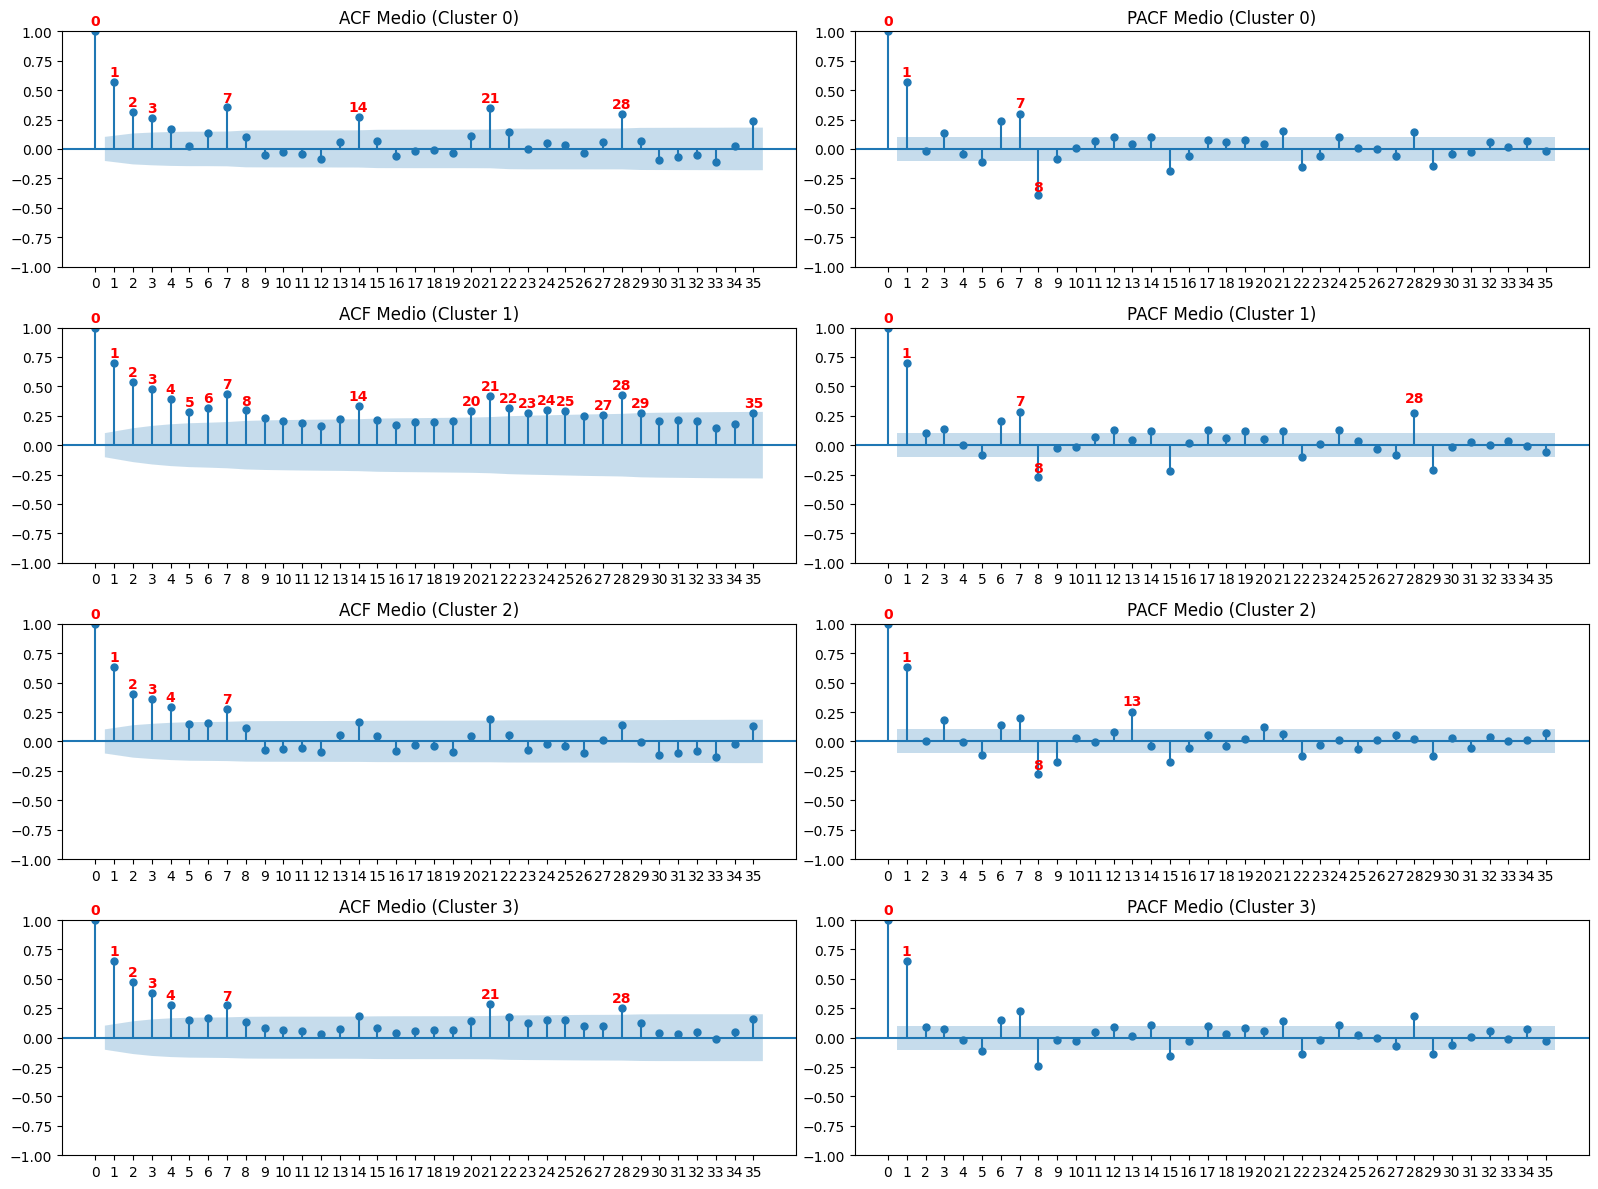

In [104]:
# Agrupamento do faturamento médio diário por cluster
df_cluster_acf = df_model.groupby(['cluster_comportamento', 'data'])['faturamento'].mean().reset_index()
clusters_unicos = sorted(df_cluster_acf['cluster_comportamento'].dropna().unique())

fig, axes = plt.subplots(len(clusters_unicos), 2, figsize=(16, 3 * len(clusters_unicos)))

# Ajuste dimensional caso exista apenas um cluster ativo
if len(clusters_unicos) == 1:
    axes = np.array([axes])

for i, cluster in enumerate(clusters_unicos):
    df_plot = df_cluster_acf[df_cluster_acf['cluster_comportamento'] == cluster].sort_values('data').set_index('data')
    ts = df_plot['faturamento'].dropna()
    
    valores_acf = acf(ts, nlags=35)
    valores_pacf = pacf(ts, nlags=35)
    
    plot_acf(ts, lags=35, ax=axes[i, 0], title=f'ACF Medio (Cluster {cluster})')
    plot_pacf(ts, lags=35, ax=axes[i, 1], title=f'PACF Medio (Cluster {cluster})')
    
    for lag, val in enumerate(valores_acf):
        if abs(val) > 0.25:
            axes[i, 0].text(lag, val + 0.05, f'{lag}', color='red', ha='center', fontweight='bold')
            
    for lag, val in enumerate(valores_pacf):
        if abs(val) > 0.25:
            axes[i, 1].text(lag, val + 0.05, f'{lag}', color='red', ha='center', fontweight='bold')
            
    axes[i, 0].set_xticks(range(0, 36))
    axes[i, 1].set_xticks(range(0, 36))

# Dicionario com os lags relevantes para cada cluster
dicionario_lags = {}

for cluster in clusters_unicos:
    df_plot = df_cluster_acf[df_cluster_acf['cluster_comportamento'] == cluster].sort_values('data').set_index('data')
    ts = df_plot['faturamento'].dropna()
    
    valores_acf = acf(ts, nlags=35)
    valores_pacf = pacf(ts, nlags=35)
    
    # Mapeamento do lag para a sua magnitude exata
    lags_acf_relevantes = {lag: round(float(val), 3) for lag, val in enumerate(valores_acf) if abs(val) > 0.25 and lag > 0}
    lags_pacf_relevantes = {lag: round(float(val), 3) for lag, val in enumerate(valores_pacf) if abs(val) > 0.25 and lag > 0}
    
    dicionario_lags[f'Cluster {cluster}'] = {
        'acf': lags_acf_relevantes,
        'pacf': lags_pacf_relevantes
    }

lags_importantes_acf = set()
lags_importantes_pacf = set()

# Cria a lista dos lags que vão virar features
print("Top 5 Lags por Cluster:\n")
for cluster, valores in dicionario_lags.items():
    # Ordena os lags pela magnitude absoluta do sinal de forma decrescente
    top_5_acf = sorted(valores['acf'].items(), key=lambda x: abs(x[1]), reverse=True)[:5]
    top_5_pacf = sorted(valores['pacf'].items(), key=lambda x: abs(x[1]), reverse=True)[:5]
    
    # Isola apenas os dias (chaves)
    lags_acf = [lag for lag, valor in top_5_acf if lag < 10]
    lags_pacf = [lag for lag, valor in top_5_pacf if lag < 10]
    
    print(f"*** {cluster} ***")
    print(f"Top 5 ACF:  {lags_acf}")
    print(f"Top 5 PACF: {lags_pacf}\n")
    
    # Insere no conjunto para evitar duplicidade na lista final
    lags_importantes_acf.update(lags_acf)
    lags_importantes_pacf.update(lags_pacf)

# Transforma os conjuntos em listas ordenadas
lags_importantes_acf = sorted(list(lags_importantes_acf))
lags_importantes_pacf = sorted(list(lags_importantes_pacf))

print("*** CONSOLIDAÇÃO GLOBAL ***")
print(f"Lista Final ACF:  {lags_importantes_acf}")
print(f"Lista Final PACF: {lags_importantes_pacf}")

plt.tight_layout()
plt.show()

In [105]:
# Criação de features dinâmicas a partir da análise de correlação
df_model = df_model.sort_values(by=['codigo_filial', 'data'])

# Criação de Lags diretos para os dias de forte impacto isolado (PACF)
for lag in lags_importantes_pacf:
    df_model[f'fat_lag_{lag}'] = df_model.groupby('codigo_filial')['faturamento'].shift(lag)

# Criação de Médias Móveis para os ciclos de memória acumulada (ACF)
for janela in lags_importantes_acf:
    df_model[f'fat_mm_{janela}'] = df_model.groupby('codigo_filial')['faturamento'].transform(
        lambda x: x.shift(1).rolling(window=janela, min_periods=1).mean()
    )

In [107]:
df_model.head()

,codigo_filial,data,faturamento,quantidade,quantidade_tickets,meta_n_med,faixa_vida,delivery,metragem_area_venda,panvel_clinic,...,is_weekend,cluster_comportamento,fat_lag_1,fat_lag_7,fat_lag_8,fat_mm_1,fat_mm_2,fat_mm_3,fat_mm_4,fat_mm_7
0,1500,2025-01-01,18077.83704,828.0,0,12732.76,2.0,0,309.0388,0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1500,2025-01-02,18077.83704,828.0,138,12732.76,2.0,0,309.0388,0,...,0,0,18077.83704,NaN,NaN,18077.83704,18077.83704,18077.83704,18077.837040,18077.837040
2,1500,2025-01-03,29631.50298,1107.0,188,12732.76,2.0,0,309.0388,0,...,0,0,18077.83704,NaN,NaN,18077.83704,18077.83704,18077.83704,18077.837040,18077.837040
3,1500,2025-01-04,14137.64100,597.0,98,12732.76,2.0,0,309.0388,0,...,1,0,29631.50298,NaN,NaN,29631.50298,23854.67001,21929.05902,21929.059020,21929.059020
4,1500,2025-01-05,18077.83704,828.0,0,12732.76,2.0,0,309.0388,0,...,1,0,14137.64100,NaN,NaN,14137.64100,21884.57199,20615.66034,19981.204515,19981.204515


## Features de calendário
- Transformação de data em informação cíclica (seno e cosseno)
- Codificação de feriados e preparação de feriados

In [108]:
# Base de calendário 
df_model['dia_do_mes'] = df_model['data'].dt.day
df_model['dia_da_semana'] = df_model['data'].dt.dayofweek
df_model['semana_do_mes'] = (df_model['data'].dt.day - 1) // 7 + 1
df_model['is_pagamento'] = df_model['dia_do_mes'].apply(lambda x: 1 if 5 <= x <= 10 else 0)

# Transformações Cíclicas - Ciclo Semanal
df_model['sin_dia_semana'] = np.sin(2 * np.pi * df_model['dia_da_semana'] / 7)
df_model['cos_dia_semana'] = np.cos(2 * np.pi * df_model['dia_da_semana'] / 7)

# Transformações Cíclicas - Ciclo Mensal (dinâmico pelo tamanho exato do mês)
dias_no_mes = df_model['data'].dt.days_in_month
df_model['sin_dia_mes'] = np.sin(2 * np.pi * df_model['dia_do_mes'] / dias_no_mes)
df_model['cos_dia_mes'] = np.cos(2 * np.pi * df_model['dia_do_mes'] / dias_no_mes)

# Flag de Feriado baseada na coluna original de eventos
df_model['is_feriado'] = (df_model['evento'] != 'Dia Comum').astype(int)

# Captura de Véspera de Feriado (antecipação de consumo)
df_model = df_model.sort_values(by=['codigo_filial', 'data'])
df_model['vespera_feriado'] = df_model.groupby('codigo_filial')['is_feriado'].shift(-1).fillna(0).astype(int)

# Captura de Semana com Feriado (impacto estendido)
df_model['ano_semana'] = df_model['data'].dt.isocalendar().year.astype(str) + '_' + df_model['data'].dt.isocalendar().week.astype(str)
mapa_semana_feriado = df_model.groupby('ano_semana')['is_feriado'].max()
df_model['is_semana_feriado'] = df_model['ano_semana'].map(mapa_semana_feriado)

# Limpeza de colunas de texto que não servem mais para o modelo
df_model = df_model.drop(columns=['evento'])

In [110]:
df_model.head()

,codigo_filial,data,faturamento,quantidade,quantidade_tickets,meta_n_med,faixa_vida,delivery,metragem_area_venda,panvel_clinic,...,semana_do_mes,is_pagamento,sin_dia_semana,cos_dia_semana,sin_dia_mes,cos_dia_mes,is_feriado,vespera_feriado,ano_semana,is_semana_feriado
0,1500,2025-01-01,18077.83704,828.0,0,12732.76,2.0,0,309.0388,0,...,1,0,0.974928,-0.222521,0.201299,0.979530,1,0,2025_1,1
1,1500,2025-01-02,18077.83704,828.0,138,12732.76,2.0,0,309.0388,0,...,1,0,0.433884,-0.900969,0.394356,0.918958,0,0,2025_1,1
2,1500,2025-01-03,29631.50298,1107.0,188,12732.76,2.0,0,309.0388,0,...,1,0,-0.433884,-0.900969,0.571268,0.820763,0,0,2025_1,1
3,1500,2025-01-04,14137.64100,597.0,98,12732.76,2.0,0,309.0388,0,...,1,0,-0.974928,-0.222521,0.724793,0.688967,0,0,2025_1,1
4,1500,2025-01-05,18077.83704,828.0,0,12732.76,2.0,0,309.0388,0,...,1,1,-0.781831,0.623490,0.848644,0.528964,0,0,2025_1,1
